# 🧠 MindScan — Notebook 2: XLM-RoBERTa + Full Comparison
### NCI H9DAI Research Project 2026

---

## Prerequisites
- ✅ Notebook 1 must be fully complete (all 18 pkl files in Drive)
- ✅ **T4 GPU must be enabled** — Runtime → Change runtime type → T4 GPU
- ✅ Your 3 CSV datasets must be uploaded to Colab again

## What this notebook does
1. Trains **XLM-RoBERTa** on each of the 3 datasets independently
2. Saves each transformer model to Drive immediately after training
3. Runs the **full 15-model comparison** (4 classical + XLM-RoBERTa per dataset)
4. Builds and tests `predict_all(text)` — the function the UI calls

## Structure — run ONE section at a time
Each XLM-RoBERTa section is fully independent. If Section 2 crashes, Sections 1 and 3 are unaffected. Come back, restart, and rerun only what failed.

| Section | Time on T4 | Output |
|---|---|---|
| Section 0 — Setup | 2 min | Libraries + Drive mount |
| Section 1 — XLM-RoBERTa D1 | ~10 min | `xlmr_d1_final/` in Drive |
| Section 2 — XLM-RoBERTa D2 | ~8 min | `xlmr_d2_final/` in Drive |
| Section 3 — XLM-RoBERTa D3 | ~10 min | `xlmr_d3_final/` in Drive |
| Section 4 — Full Comparison | 5 min | Charts + master table |
| Section 5 — predict_all() | 5 min | Live demo of UI function |

---
# ⚙️ SECTION 0 — Setup

**Run this every time you open the notebook**, even if you're continuing from a previous session.

In [3]:
# Check GPU is available — MUST be T4 before continuing
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                         '--format=csv,noheader'], capture_output=True, text=True)
if result.returncode == 0:
    print(f'✅ GPU detected: {result.stdout.strip()}')
else:
    print('❌ NO GPU DETECTED')
    print('   Go to Runtime → Change runtime type → T4 GPU → Save')
    print('   Then re-run this cell.')

✅ GPU detected: Tesla T4, 15360 MiB


In [4]:
!pip install -q transformers datasets accelerate scikit-learn xgboost imbalanced-learn
!pip install -q matplotlib seaborn pandas numpy joblib
print('✅ Libraries installed!')

✅ Libraries installed!


In [5]:
import pandas as pd
import numpy as np
import re, string, os, joblib, json, warnings, shutil
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset as HFDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, cohen_kappa_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports complete. Using device: {device}')

✅ Imports complete. Using device: cuda


In [6]:
# ─────────────────────────────────────────────────────────────────
# MOUNT GOOGLE DRIVE — loads classical results, saves transformer files
# ─────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

CLASSICAL_DIR   = '/content/drive/MyDrive/MindScan_Models/classical'
TRANSFORMER_DIR = '/content/drive/MyDrive/MindScan_Models/transformers'
os.makedirs(TRANSFORMER_DIR, exist_ok=True)

# Verify classical models are present from Notebook 1
expected = ['tfidf_d1.pkl','le_d1.pkl','tfidf_d2.pkl','le_d2.pkl','tfidf_d3.pkl','le_d3.pkl']
missing = [f for f in expected if not os.path.exists(os.path.join(CLASSICAL_DIR, f))]

if missing:
    print(f'❌ Missing files from Notebook 1: {missing}')
    print('   Complete Notebook 1 first before running this notebook.')
else:
    print('✅ All Notebook 1 files found in Drive.')
    print(f'   Transformer models will be saved to: {TRANSFORMER_DIR}')

Mounted at /content/drive
✅ All Notebook 1 files found in Drive.
   Transformer models will be saved to: /content/drive/MyDrive/MindScan_Models/transformers


In [7]:
# ─────────────────────────────────────────────────────────────────
# SHARED FUNCTIONS — same clean_text and evaluate from Notebook 1
# ─────────────────────────────────────────────────────────────────

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def evaluate_transformer(name, y_true, y_pred, label_names, ds_key, results_store):
    """
    Same evaluation function as Notebook 1 but saves confusion matrix
    to the transformers folder in Drive.
    """
    acc   = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)

    results_store[name] = {
        'accuracy': round(acc, 4),
        'macro_f1': round(macro, 4),
        'kappa':    round(kappa, 4)
    }

    print(f'\n{"="*55}')
    print(f'  {name}  [{ds_key}]')
    print(f'{"="*55}')
    print(f'  Accuracy     : {acc*100:.2f}%')
    print(f'  Macro F1     : {macro:.4f}   ← main metric')
    print(f"  Cohen's Kappa: {kappa:.4f}")
    print(f'{"="*55}\n')
    print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(label_names)*1.4), max(5, len(label_names)*1.1)))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=label_names, yticklabels=label_names,
                cmap='Purples', linewidths=0.4)
    plt.title(f'Confusion Matrix — {name}  [{ds_key}]', fontsize=12, fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    chart_path = os.path.join(TRANSFORMER_DIR, f'cm_{ds_key}_XLM-RoBERTa.png')
    plt.savefig(chart_path, dpi=120, bbox_inches='tight')
    plt.show()


def save_transformer(model, tokenizer_obj, folder_name):
    """
    Saves XLM-RoBERTa model + tokenizer to Drive.
    Saves to both local and Drive.
    """
    local_path = f'./{folder_name}'
    drive_path = os.path.join(TRANSFORMER_DIR, folder_name)

    model.save_pretrained(local_path)
    tokenizer_obj.save_pretrained(local_path)

    if os.path.exists(drive_path):
        shutil.rmtree(drive_path)
    shutil.copytree(local_path, drive_path)

    files = os.listdir(local_path)
    size_mb = sum(os.path.getsize(os.path.join(local_path,f))
                  for f in files) / 1024 / 1024
    print(f'✅ Saved {folder_name}/ → Drive  ({size_mb:.0f} MB, {len(files)} files)')


# Global store for all results (classical + transformer)
ALL_RESULTS = {}

# Load classical results from Notebook 1
classical_csv = os.path.join(CLASSICAL_DIR, 'classical_results.csv')
if os.path.exists(classical_csv):
    classical_df = pd.read_csv(classical_csv)
    print('✅ Classical results loaded from Drive:')
    print(classical_df.to_string(index=False))
else:
    classical_df = None
    print('⚠️  classical_results.csv not found — run Notebook 1 first.')

MODEL_NAME = 'xlm-roberta-base'
print(f'\n✅ All shared functions ready. Model: {MODEL_NAME}')

✅ Classical results loaded from Drive:
             Dataset               Model  Accuracy  Macro F1  Cohen's Kappa
  D1 Depression Type Logistic Regression    0.9152    0.9179         0.8971
  D1 Depression Type       Random Forest    0.9089    0.9129         0.8891
  D1 Depression Type                 SVM    0.9236    0.9269         0.9072
  D1 Depression Type             XGBoost    0.9176    0.9217         0.9000
D2 Binary Depression Logistic Regression    0.9889    0.9839         0.9678
D2 Binary Depression       Random Forest    0.9918    0.9880         0.9760
D2 Binary Depression                 SVM    0.9709    0.9589         0.9177
D2 Binary Depression             XGBoost    0.9927    0.9895         0.9789
     D3 Suicide Risk Logistic Regression    0.9318    0.9318         0.8636
     D3 Suicide Risk       Random Forest    0.8800    0.8800         0.7600
     D3 Suicide Risk                 SVM    0.9368    0.9368         0.8736
     D3 Suicide Risk             XGBoost    0.916

---
# 🤖 SECTION 1 — XLM-RoBERTa: Dataset 1 (Depression Type)

**What is XLM-RoBERTa and why is it better than word2vec?**

The base paper (Tumaliuan et al. 2024) used **word2vec** — a 2013 algorithm that gives every word one fixed vector regardless of context. `bank` always means the same thing whether in `river bank` or `bank account`.

XLM-RoBERTa (2019) creates **contextual embeddings** — the same word gets a different vector depending on its surrounding words. For depression detection this matters critically:
- `I can't sleep` vs `I can sleep fine` — same words, opposite meaning
- `I'm not fine` vs `I'm fine` — XLM-RoBERTa understands negation, word2vec does not

It was pre-trained on 2.5TB of text across 100 languages. We **fine-tune** it — meaning we take those pre-learned language patterns and train them further on our specific depression dataset.

**Upload `dataset.csv` before running this section.**

In [9]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1 STEP 1 — Load D1 data + label encoder from Drive
# ─────────────────────────────────────────────────────────────────
df1 = pd.read_csv('DA_1_DB.csv')
df1 = df1.dropna(subset=['Tweets','Labels'])
df1 = df1[df1['Labels'].str.strip() != ''].reset_index(drop=True)
print(f'D1 loaded: {len(df1):,} rows')

# Load the label encoder saved in Notebook 1
le1 = joblib.load(os.path.join(CLASSICAL_DIR, 'le_d1.pkl'))
print(f'Label encoder loaded: {list(le1.classes_)}')

# Clean and encode
df1['clean'] = df1['Tweets'].apply(clean_text)
df1['label_enc'] = le1.transform(df1['Labels'])

X1 = df1['clean']
y1 = df1['label_enc']

# Same 80/20 split — MUST use same random_state=42 as Notebook 1
# so test set is identical and results are directly comparable
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=42
)
print(f'Split: {len(X1_tr)} train / {len(X1_te)} test')
print('✅ D1 data ready for XLM-RoBERTa.')

D1 loaded: 14,983 rows
Label encoder loaded: ['atypical', 'bipolar', 'major depressive', 'no', 'postpartum', 'psychotic']
Split: 11986 train / 2997 test
✅ D1 data ready for XLM-RoBERTa.


In [10]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1 STEP 2 — Tokenise D1 for XLM-RoBERTa
#
# XLM-RoBERTa cannot read raw text. The tokeniser splits words into
# sub-word pieces and converts them to IDs the model understands.
# max_length=128 is enough for tweets (avg 31 words ≈ 40 tokens).
# ─────────────────────────────────────────────────────────────────
print('Loading tokeniser...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokeniser loaded.')

def tokenize_tweets(examples):
    """Tokenises short tweet-length texts. max_length=128."""
    return tokenizer(
        examples['text'],
        max_length=128,
        truncation=True,
        padding='max_length'
    )

train1_hf = HFDataset.from_dict({'text': list(X1_tr), 'label': list(y1_tr)})
test1_hf  = HFDataset.from_dict({'text': list(X1_te), 'label': list(y1_te)})

print('Tokenising training set...')
train1_tok = train1_hf.map(tokenize_tweets, batched=True)
print('Tokenising test set...')
test1_tok  = test1_hf.map(tokenize_tweets,  batched=True)

print(f'✅ Tokenisation complete. Example token count: 128 per tweet.')

Loading tokeniser...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokeniser loaded.
Tokenising training set...


Map:   0%|          | 0/11986 [00:00<?, ? examples/s]

Tokenising test set...


Map:   0%|          | 0/2997 [00:00<?, ? examples/s]

✅ Tokenisation complete. Example token count: 128 per tweet.


In [11]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1 STEP 3 — Load model + set up weighted loss
#
# We load XLM-RoBERTa pre-trained and add a 6-class output head.
# The UNEXPECTED/MISSING messages in the output are NORMAL —
# they just mean the classification head is newly initialised
# (which is correct — we haven't trained it yet).
#
# Weighted loss = the model pays MORE attention to rare classes
# during training. This replaces SMOTE for transformers.
# ─────────────────────────────────────────────────────────────────
NUM_LABELS_D1 = len(le1.classes_)
print(f'Loading XLM-RoBERTa with {NUM_LABELS_D1} output classes...')
xlmr_d1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_D1
)
print(f'✅ Model loaded. Parameters: {sum(p.numel() for p in xlmr_d1.parameters()):,}')

# Class weights — inverse frequency so rare classes get more attention
cw1 = compute_class_weight('balanced', classes=np.unique(y1_tr), y=y1_tr)
cw1_tensor = torch.tensor(cw1, dtype=torch.float).to(device)

print('\nClass weights (higher = model pays more attention):')
for cls, w in zip(le1.classes_, cw1):
    print(f'  {cls:<20}: {w:.3f}')

class WeightedTrainer1(Trainer):
    """Custom trainer that applies class weights to the loss.
    Handles class imbalance at transformer level."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=cw1_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print('✅ Weighted trainer ready.')

Loading XLM-RoBERTa with 6 output classes...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded. Parameters: 278,048,262

Class weights (higher = model pays more attention):
  atypical            : 1.261
  bipolar             : 1.022
  major depressive    : 0.992
  no                  : 1.258
  postpartum          : 0.667
  psychotic           : 1.080
✅ Weighted trainer ready.


In [12]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1 STEP 4 — Fine-tune XLM-RoBERTa on D1
#
# Fine-tuning = taking the pre-trained model and continuing to
# train it on our specific dataset for a few more passes.
#
# Key settings:
#   num_train_epochs=3   — 3 full passes through the data
#   learning_rate=2e-5   — standard BERT fine-tuning rate
#   warmup_steps=200     — gradually increase LR at start
#   fp16=True            — half-precision maths, 2× faster on GPU
#   load_best_model_at_end — keeps the epoch with lowest val loss
# ─────────────────────────────────────────────────────────────────
args_d1 = TrainingArguments(
    output_dir='./xlmr_d1_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    report_to='none',
    logging_steps=50
)

trainer_d1 = WeightedTrainer1(
    model=xlmr_d1,
    args=args_d1,
    train_dataset=train1_tok,
    eval_dataset=test1_tok
)

print('Starting fine-tuning — Dataset 1 (Depression Type)...')
print('Expected time: ~10 minutes on T4 GPU')
print()
trainer_d1.train()

Starting fine-tuning — Dataset 1 (Depression Type)...
Expected time: ~10 minutes on T4 GPU



Epoch,Training Loss,Validation Loss
1,0.247780,0.245682
2,0.234184,0.260968
3,0.138115,0.246992


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2250, training_loss=0.3156498196919759, metrics={'train_runtime': 621.2666, 'train_samples_per_second': 57.879, 'train_steps_per_second': 3.622, 'total_flos': 2365321778187264.0, 'train_loss': 0.3156498196919759, 'epoch': 3.0})

Getting predictions...



  XLM-RoBERTa  [D1]
  Accuracy     : 90.52%
  Macro F1     : 0.9117   ← main metric
  Cohen's Kappa: 0.8852

                  precision    recall  f1-score   support

        atypical      0.997     0.987     0.992       396
         bipolar      0.923     0.961     0.942       489
major depressive      0.752     0.841     0.794       504
              no      0.995     0.967     0.981       397
      postpartum      0.947     0.866     0.905       749
       psychotic      0.857     0.855     0.856       462

        accuracy                          0.905      2997
       macro avg      0.912     0.913     0.912      2997
    weighted avg      0.910     0.905     0.906      2997



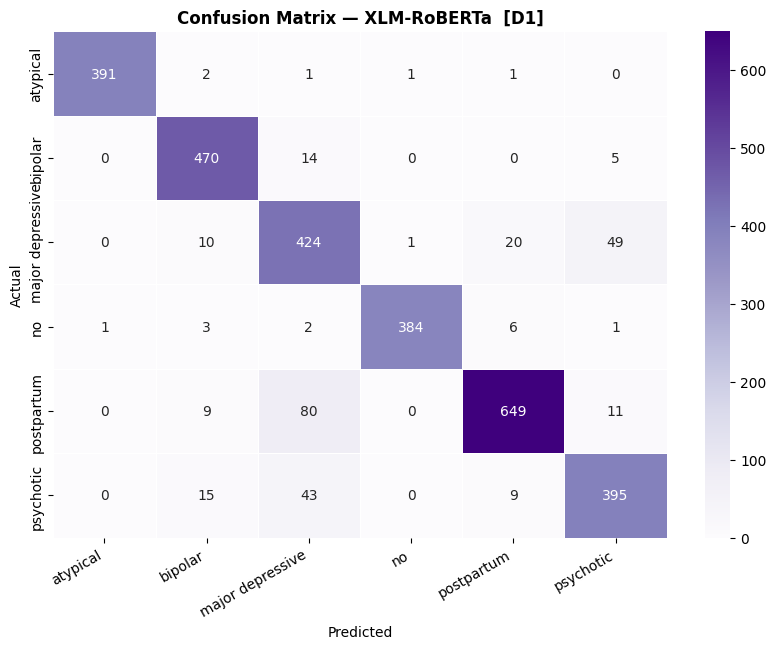

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved xlmr_d1_final/ → Drive  (1077 MB, 4 files)

✅ Section 1 complete!
   XLM-RoBERTa D1 F1: 0.9117
   GPU memory cleared for Section 2.


In [13]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1 STEP 5 — Evaluate + Save D1 transformer
# ─────────────────────────────────────────────────────────────────
print('Getting predictions...')
raw_out1 = trainer_d1.predict(test1_tok)

# argmax picks the class with the highest probability score
preds_d1 = np.argmax(raw_out1.predictions, axis=1)

d1_xlmr_results = {}
evaluate_transformer('XLM-RoBERTa', y1_te, preds_d1, le1.classes_, 'D1', d1_xlmr_results)

# Save model + tokenizer to Drive
save_transformer(xlmr_d1, tokenizer, 'xlmr_d1_final')

# Store result for comparison
ALL_RESULTS['D1 XLM-RoBERTa'] = d1_xlmr_results['XLM-RoBERTa']

print(f'\n✅ Section 1 complete!')
print(f'   XLM-RoBERTa D1 F1: {d1_xlmr_results["XLM-RoBERTa"]["macro_f1"]}')

# Free GPU memory before next section
del xlmr_d1, trainer_d1
torch.cuda.empty_cache()
print('   GPU memory cleared for Section 2.')

---
# 🤖 SECTION 2 — XLM-RoBERTa: Dataset 2 (Binary Depression)

Binary classification is simpler than 6-class so we expect higher F1 scores here.

**Upload `DA_DB_2.csv` before running this section.**

In [14]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2 STEP 1 — Load D2
# ─────────────────────────────────────────────────────────────────
df2 = pd.read_csv('DA_DB_2.csv')
df2 = df2.rename(columns={
    'message to examine': 'text',
    'label (depression result)': 'label'
})
if 'Index' in df2.columns:
    df2 = df2.drop(columns=['Index'])

df2 = df2[['text','label']].dropna().reset_index(drop=True)
df2['label'] = df2['label'].astype(str).str.strip().str.lower()
df2['clean'] = df2['text'].apply(clean_text)

le2 = joblib.load(os.path.join(CLASSICAL_DIR, 'le_d2.pkl'))
df2['label_enc'] = le2.transform(df2['label'])

X2 = df2['clean']; y2 = df2['label_enc']

# Same random_state=42 — identical test set as Notebook 1
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)
print(f'D2: {len(X2_tr)} train / {len(X2_te)} test')
print(f'Classes: {list(le2.classes_)}')

D2: 8251 train / 2063 test
Classes: ['0', '1']


In [15]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2 STEP 2 — Tokenise D2
# Same tokenise_tweets function — tweets so max_length=128
# ─────────────────────────────────────────────────────────────────
train2_hf = HFDataset.from_dict({'text': list(X2_tr), 'label': list(y2_tr)})
test2_hf  = HFDataset.from_dict({'text': list(X2_te), 'label': list(y2_te)})

print('Tokenising D2...')
train2_tok = train2_hf.map(tokenize_tweets, batched=True)
test2_tok  = test2_hf.map(tokenize_tweets,  batched=True)
print('✅ D2 tokenised.')

Tokenising D2...


Map:   0%|          | 0/8251 [00:00<?, ? examples/s]

Map:   0%|          | 0/2063 [00:00<?, ? examples/s]

✅ D2 tokenised.


In [16]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2 STEP 3 — Load model + weighted loss for D2
# ─────────────────────────────────────────────────────────────────
NUM_LABELS_D2 = len(le2.classes_)
xlmr_d2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_D2
)
print(f'✅ Model loaded for D2 ({NUM_LABELS_D2} classes).')

cw2 = compute_class_weight('balanced', classes=np.unique(y2_tr), y=y2_tr)
cw2_tensor = torch.tensor(cw2, dtype=torch.float).to(device)

print('Class weights:')
for cls, w in zip(le2.classes_, cw2):
    print(f'  {cls}: {w:.3f}')

class WeightedTrainer2(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=cw2_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded for D2 (2 classes).
Class weights:
  0: 0.645
  1: 2.229


In [17]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2 STEP 4 — Fine-tune XLM-RoBERTa on D2
# Binary is simpler — uses batch_size=32 for faster training
# ─────────────────────────────────────────────────────────────────
args_d2 = TrainingArguments(
    output_dir='./xlmr_d2_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=200,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    report_to='none',
    logging_steps=50
)

trainer_d2 = WeightedTrainer2(
    model=xlmr_d2, args=args_d2,
    train_dataset=train2_tok, eval_dataset=test2_tok
)

print('Fine-tuning — Dataset 2 (Binary Depression)...')
print('Expected time: ~8 minutes on T4 GPU')
print()
trainer_d2.train()

Fine-tuning — Dataset 2 (Binary Depression)...
Expected time: ~8 minutes on T4 GPU



Epoch,Training Loss,Validation Loss
1,0.053907,0.007455
2,0.016556,0.004306
3,0.000532,0.001125


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=774, training_loss=0.09506019873867047, metrics={'train_runtime': 458.7069, 'train_samples_per_second': 53.963, 'train_steps_per_second': 1.687, 'total_flos': 1628196988331520.0, 'train_loss': 0.09506019873867047, 'epoch': 3.0})


  XLM-RoBERTa  [D2]
  Accuracy     : 99.95%
  Macro F1     : 0.9993   ← main metric
  Cohen's Kappa: 0.9986

              precision    recall  f1-score   support

           0      0.999     1.000     1.000      1600
           1      1.000     0.998     0.999       463

    accuracy                          1.000      2063
   macro avg      1.000     0.999     0.999      2063
weighted avg      1.000     1.000     1.000      2063



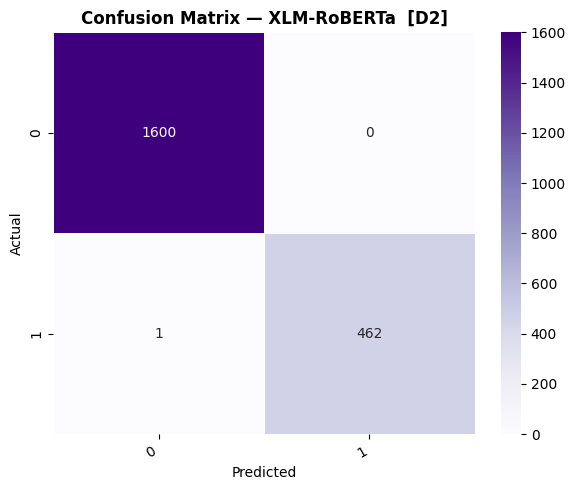

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved xlmr_d2_final/ → Drive  (1077 MB, 4 files)

✅ Section 2 complete!
   XLM-RoBERTa D2 F1: 0.9993
   GPU memory cleared for Section 3.


In [18]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2 STEP 5 — Evaluate + Save D2
# ─────────────────────────────────────────────────────────────────
preds_d2 = np.argmax(trainer_d2.predict(test2_tok).predictions, axis=1)

d2_xlmr_results = {}
evaluate_transformer('XLM-RoBERTa', y2_te, preds_d2, le2.classes_, 'D2', d2_xlmr_results)

save_transformer(xlmr_d2, tokenizer, 'xlmr_d2_final')

ALL_RESULTS['D2 XLM-RoBERTa'] = d2_xlmr_results['XLM-RoBERTa']

print(f'\n✅ Section 2 complete!')
print(f'   XLM-RoBERTa D2 F1: {d2_xlmr_results["XLM-RoBERTa"]["macro_f1"]}')

del xlmr_d2, trainer_d2
torch.cuda.empty_cache()
print('   GPU memory cleared for Section 3.')

---
# 🤖 SECTION 3 — XLM-RoBERTa: Dataset 3 (Suicide Risk)

**Key difference from D1 and D2:**  
Reddit posts are much longer than tweets — average 236 words vs 31 for tweets.  
We use `max_length=256` instead of 128 to capture more of each post's context.

**Upload `DA_DB_3.csv` before running this section.**

In [19]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3 STEP 1 — Load D3
# ─────────────────────────────────────────────────────────────────
df3 = pd.read_csv('DA_DB_3.csv')

# Standardise columns
rename_map = {}
for col in df3.columns:
    if col.lower() == 'class': rename_map[col] = 'label'
    elif col.lower() == 'text': rename_map[col] = 'text'
df3 = df3.rename(columns=rename_map)

df3 = df3[['text','label']].dropna().reset_index(drop=True)
df3['label'] = df3['label'].astype(str).str.strip().str.lower()

# Sample 25K per class (same as Notebook 1)
df3 = df3.groupby('label').apply(
    lambda x: x.sample(min(25000, len(x)), random_state=42)
).reset_index(drop=True)

df3['clean'] = df3['text'].apply(clean_text)

le3 = joblib.load(os.path.join(CLASSICAL_DIR, 'le_d3.pkl'))
df3['label_enc'] = le3.transform(df3['label'])

X3 = df3['clean']; y3 = df3['label_enc']

# Same random_state=42 — identical test set as Notebook 1
X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.2, stratify=y3, random_state=42
)
print(f'D3: {len(X3_tr)} train / {len(X3_te)} test')
print(f'Classes: {list(le3.classes_)}')

D3: 40000 train / 10000 test
Classes: ['non-suicide', 'suicide']


In [20]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3 STEP 2 — Tokenise D3
#
# Reddit posts are much longer than tweets.
# max_length=256 captures ~200 words of context per post.
# This means each batch uses 2× memory vs D1/D2
# so we reduce batch_size to 8 to avoid OOM errors.
# ─────────────────────────────────────────────────────────────────
def tokenize_reddit(examples):
    """For Reddit posts — longer texts need more tokens (256 vs 128)."""
    return tokenizer(
        examples['text'],
        max_length=256,
        truncation=True,
        padding='max_length'
    )

train3_hf = HFDataset.from_dict({'text': list(X3_tr), 'label': list(y3_tr)})
test3_hf  = HFDataset.from_dict({'text': list(X3_te), 'label': list(y3_te)})

print('Tokenising D3 (max_length=256, slower than D1/D2)...')
train3_tok = train3_hf.map(tokenize_reddit, batched=True)
test3_tok  = test3_hf.map(tokenize_reddit,  batched=True)
print('✅ D3 tokenised.')

Tokenising D3 (max_length=256, slower than D1/D2)...


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ D3 tokenised.


In [21]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3 STEP 3 — Load model for D3
# D3 is balanced so no class weights needed — standard Trainer
# ─────────────────────────────────────────────────────────────────
NUM_LABELS_D3 = len(le3.classes_)
xlmr_d3 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_D3
)
print(f'✅ Model loaded for D3 ({NUM_LABELS_D3} classes).')
print('Dataset is balanced — using standard Trainer (no class weights needed).')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded for D3 (2 classes).
Dataset is balanced — using standard Trainer (no class weights needed).


In [22]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3 STEP 4 — Fine-tune XLM-RoBERTa on D3
#
# batch_size=8 because max_length=256 uses 2× the memory.
# gradient_accumulation_steps=2 simulates batch_size=16
# without running out of GPU memory.
# ─────────────────────────────────────────────────────────────────
args_d3 = TrainingArguments(
    output_dir='./xlmr_d3_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    warmup_steps=300,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    report_to='none',
    logging_steps=50
)

trainer_d3 = Trainer(
    model=xlmr_d3, args=args_d3,
    train_dataset=train3_tok, eval_dataset=test3_tok
)

print('Fine-tuning — Dataset 3 (Suicide Risk)...')
print('Expected time: ~12 minutes on T4 GPU (longer posts = more compute)')
print()
trainer_d3.train()

Fine-tuning — Dataset 3 (Suicide Risk)...
Expected time: ~12 minutes on T4 GPU (longer posts = more compute)



Epoch,Training Loss,Validation Loss
1,0.171100,0.123076
2,0.127004,0.090145
3,0.056179,0.110482


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7500, training_loss=0.19976090299288432, metrics={'train_runtime': 2542.4152, 'train_samples_per_second': 47.199, 'train_steps_per_second': 2.95, 'total_flos': 1.57866633216e+16, 'train_loss': 0.19976090299288432, 'epoch': 3.0})


  XLM-RoBERTa  [D3]
  Accuracy     : 98.10%
  Macro F1     : 0.9810   ← main metric
  Cohen's Kappa: 0.9620

              precision    recall  f1-score   support

 non-suicide      0.980     0.982     0.981      5000
     suicide      0.982     0.980     0.981      5000

    accuracy                          0.981     10000
   macro avg      0.981     0.981     0.981     10000
weighted avg      0.981     0.981     0.981     10000



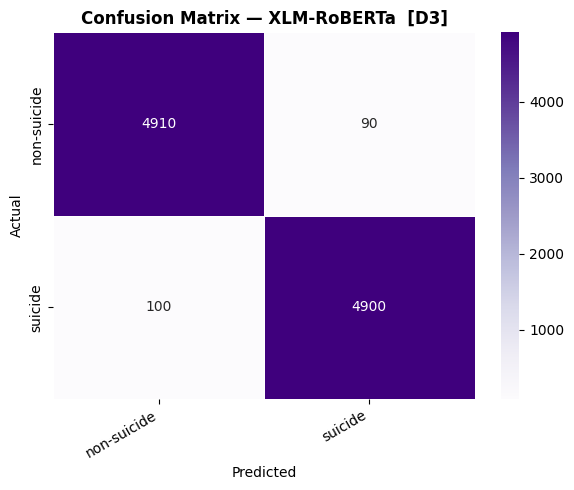

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved xlmr_d3_final/ → Drive  (1077 MB, 4 files)

✅ Section 3 complete!
   XLM-RoBERTa D3 F1: 0.981
   GPU memory cleared.


In [23]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3 STEP 5 — Evaluate + Save D3
# ─────────────────────────────────────────────────────────────────
preds_d3 = np.argmax(trainer_d3.predict(test3_tok).predictions, axis=1)

d3_xlmr_results = {}
evaluate_transformer('XLM-RoBERTa', y3_te, preds_d3, le3.classes_, 'D3', d3_xlmr_results)

save_transformer(xlmr_d3, tokenizer, 'xlmr_d3_final')

ALL_RESULTS['D3 XLM-RoBERTa'] = d3_xlmr_results['XLM-RoBERTa']

print(f'\n✅ Section 3 complete!')
print(f'   XLM-RoBERTa D3 F1: {d3_xlmr_results["XLM-RoBERTa"]["macro_f1"]}')

del xlmr_d3, trainer_d3
torch.cuda.empty_cache()
print('   GPU memory cleared.')

---
# 📊 SECTION 4 — Full Comparison: All 5 Models × 3 Datasets

All 15 models trained. Now we combine the classical results from Notebook 1 with the XLM-RoBERTa results from this notebook and compare everything.

In [24]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4.1 — Build master results table
#
# Merges classical results (from classical_results.csv in Drive)
# with XLM-RoBERTa results collected in this notebook.
# ─────────────────────────────────────────────────────────────────

# Classical results from Notebook 1
classical_df = pd.read_csv(os.path.join(CLASSICAL_DIR, 'classical_results.csv'))

# XLM-RoBERTa results from this notebook
transformer_rows = [
    {'Dataset': 'D1 Depression Type', 'Model': 'XLM-RoBERTa',
     'Accuracy': ALL_RESULTS['D1 XLM-RoBERTa']['accuracy'],
     'Macro F1': ALL_RESULTS['D1 XLM-RoBERTa']['macro_f1'],
     "Cohen's Kappa": ALL_RESULTS['D1 XLM-RoBERTa']['kappa']},
    {'Dataset': 'D2 Binary Depression', 'Model': 'XLM-RoBERTa',
     'Accuracy': ALL_RESULTS['D2 XLM-RoBERTa']['accuracy'],
     'Macro F1': ALL_RESULTS['D2 XLM-RoBERTa']['macro_f1'],
     "Cohen's Kappa": ALL_RESULTS['D2 XLM-RoBERTa']['kappa']},
    {'Dataset': 'D3 Suicide Risk', 'Model': 'XLM-RoBERTa',
     'Accuracy': ALL_RESULTS['D3 XLM-RoBERTa']['accuracy'],
     'Macro F1': ALL_RESULTS['D3 XLM-RoBERTa']['macro_f1'],
     "Cohen's Kappa": ALL_RESULTS['D3 XLM-RoBERTa']['kappa']},
]
transformer_df = pd.DataFrame(transformer_rows)

# Combine
master = pd.concat([classical_df, transformer_df], ignore_index=True)

# Save full master table
master.to_csv(os.path.join(TRANSFORMER_DIR, 'full_results.csv'), index=False)

print('=' * 65)
print('  MASTER RESULTS — ALL 15 MODELS (5 × 3 DATASETS)')
print('=' * 65)
print(master.to_string(index=False))
print()

# Best model per dataset
print('Best model per dataset (by Macro F1):')
best = master.loc[master.groupby('Dataset')['Macro F1'].idxmax()]
for _, row in best.iterrows():
    print(f"  {row['Dataset']:<25}: {row['Model']:<22} F1={row['Macro F1']:.4f}")

  MASTER RESULTS — ALL 15 MODELS (5 × 3 DATASETS)
             Dataset               Model  Accuracy  Macro F1  Cohen's Kappa
  D1 Depression Type Logistic Regression    0.9152    0.9179         0.8971
  D1 Depression Type       Random Forest    0.9089    0.9129         0.8891
  D1 Depression Type                 SVM    0.9236    0.9269         0.9072
  D1 Depression Type             XGBoost    0.9176    0.9217         0.9000
D2 Binary Depression Logistic Regression    0.9889    0.9839         0.9678
D2 Binary Depression       Random Forest    0.9918    0.9880         0.9760
D2 Binary Depression                 SVM    0.9709    0.9589         0.9177
D2 Binary Depression             XGBoost    0.9927    0.9895         0.9789
     D3 Suicide Risk Logistic Regression    0.9318    0.9318         0.8636
     D3 Suicide Risk       Random Forest    0.8800    0.8800         0.7600
     D3 Suicide Risk                 SVM    0.9368    0.9368         0.8736
     D3 Suicide Risk             XGBoo

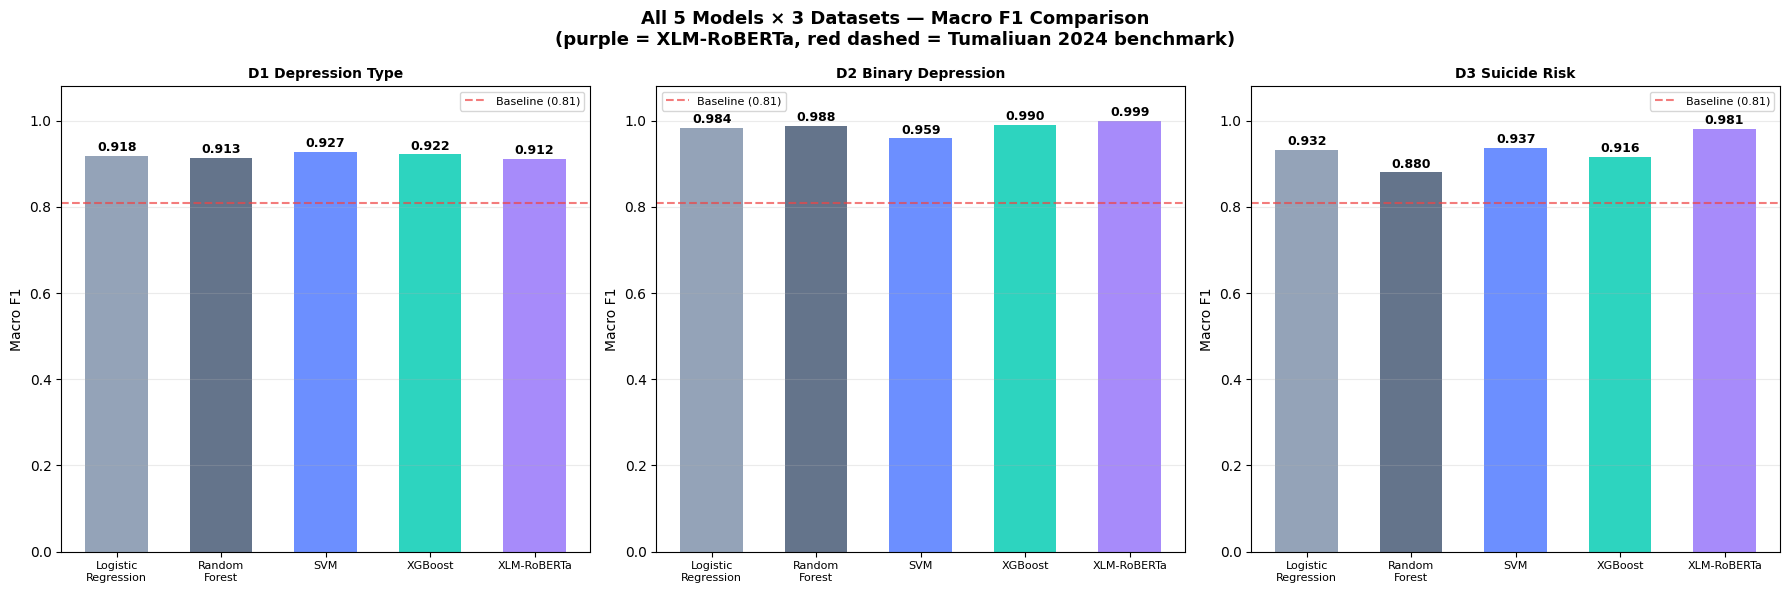

Chart saved: /content/drive/MyDrive/MindScan_Models/transformers/full_comparison.png


In [25]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4.2 — Full comparison chart (all 5 models, all 3 datasets)
#
# This is the headline chart for your paper and presentation.
# XLM-RoBERTa bar is purple, classical models are grey/blue/teal.
# Red dashed line = Tumaliuan et al. 2024 benchmark (F1=0.81).
# ─────────────────────────────────────────────────────────────────

model_order  = ['Logistic Regression','Random Forest','SVM','XGBoost','XLM-RoBERTa']
model_colors = {
    'Logistic Regression': '#94a3b8',
    'Random Forest':        '#64748b',
    'SVM':                  '#6c8fff',
    'XGBoost':              '#2dd4bf',
    'XLM-RoBERTa':          '#a78bfa',
}

datasets = master['Dataset'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('All 5 Models × 3 Datasets — Macro F1 Comparison\n(purple = XLM-RoBERTa, red dashed = Tumaliuan 2024 benchmark)',
             fontsize=13, fontweight='bold')

for ax, ds in zip(axes, datasets):
    ds_data = master[master['Dataset'] == ds].set_index('Model')
    models  = [m for m in model_order if m in ds_data.index]
    f1s     = [ds_data.loc[m,'Macro F1'] for m in models]
    colors  = [model_colors[m] for m in models]

    bars = ax.bar(range(len(models)), f1s, color=colors, edgecolor='none', width=0.6)

    # Value labels on bars
    for bar, score in zip(bars, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Benchmark line
    ax.axhline(0.81, color='#ef4444', linestyle='--', linewidth=1.5,
               alpha=0.7, label='Baseline (0.81)')

    ax.set_title(ds, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
chart_path = os.path.join(TRANSFORMER_DIR, 'full_comparison.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')

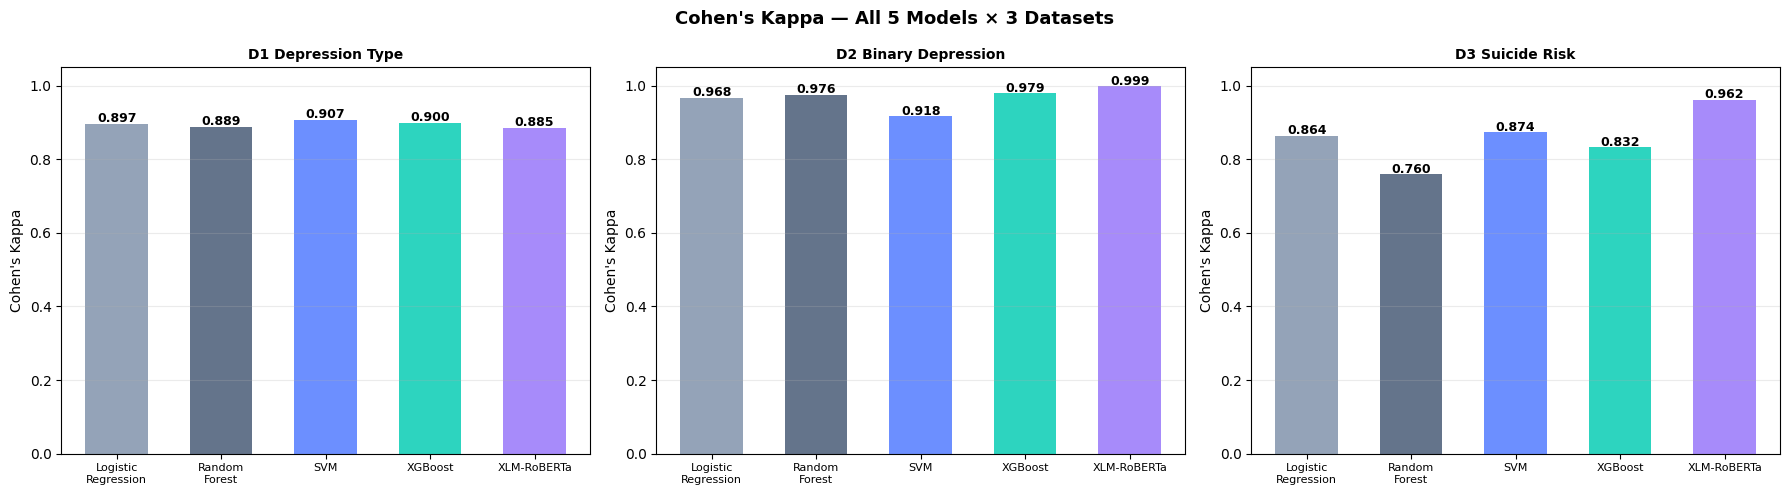

In [26]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4.3 — Cohen's Kappa comparison chart
#
# The assignment requires multiple metrics beyond just F1.
# This chart shows Cohen's Kappa — measures agreement beyond chance.
# A kappa of 0 means no better than random; 1.0 means perfect.
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cohen's Kappa — All 5 Models × 3 Datasets",
             fontsize=13, fontweight='bold')

for ax, ds in zip(axes, datasets):
    ds_data = master[master['Dataset'] == ds].set_index('Model')
    models  = [m for m in model_order if m in ds_data.index]
    kappas  = [ds_data.loc[m,"Cohen's Kappa"] for m in models]
    colors  = [model_colors[m] for m in models]

    bars = ax.bar(range(len(models)), kappas, color=colors, edgecolor='none', width=0.6)
    for bar, k in zip(bars, kappas):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{k:.3f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(ds, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
    ax.set_ylabel("Cohen's Kappa")
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(TRANSFORMER_DIR, 'kappa_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# 🔌 SECTION 5 — predict_all() — The UI Function

This is the function the UI calls when a user submits text. It:
1. Runs through all 5 models on all 3 datasets (15 predictions total)
2. Returns every model's prediction + confidence
3. Identifies the winner per dataset (highest confidence)
4. Flags suicide risk if majority of D3 models agree

**In the UI** — all 5 model results are shown side by side so users can see the model comparison simulation. The winner is highlighted with a star.

In [27]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5.1 — Load everything
#
# Loads all 18 classical pkl files from Drive +
# 3 XLM-RoBERTa models from their local saved folders.
# ─────────────────────────────────────────────────────────────────

print('Loading classical models from Drive...')

# Support files
le1    = joblib.load(os.path.join(CLASSICAL_DIR, 'le_d1.pkl'))
le2    = joblib.load(os.path.join(CLASSICAL_DIR, 'le_d2.pkl'))
le3    = joblib.load(os.path.join(CLASSICAL_DIR, 'le_d3.pkl'))
tfidf1 = joblib.load(os.path.join(CLASSICAL_DIR, 'tfidf_d1.pkl'))
tfidf2 = joblib.load(os.path.join(CLASSICAL_DIR, 'tfidf_d2.pkl'))
tfidf3 = joblib.load(os.path.join(CLASSICAL_DIR, 'tfidf_d3.pkl'))

# Classical models — Dataset 1
lr1  = joblib.load(os.path.join(CLASSICAL_DIR, 'logistic_regression_d1.pkl'))
rf1  = joblib.load(os.path.join(CLASSICAL_DIR, 'random_forest_d1.pkl'))
svm1 = joblib.load(os.path.join(CLASSICAL_DIR, 'svm_d1.pkl'))
xgb1 = joblib.load(os.path.join(CLASSICAL_DIR, 'xgboost_d1.pkl'))

# Classical models — Dataset 2
lr2  = joblib.load(os.path.join(CLASSICAL_DIR, 'logistic_regression_d2.pkl'))
rf2  = joblib.load(os.path.join(CLASSICAL_DIR, 'random_forest_d2.pkl'))
svm2 = joblib.load(os.path.join(CLASSICAL_DIR, 'svm_d2.pkl'))
xgb2 = joblib.load(os.path.join(CLASSICAL_DIR, 'xgboost_d2.pkl'))

# Classical models — Dataset 3
lr3  = joblib.load(os.path.join(CLASSICAL_DIR, 'logistic_regression_d3.pkl'))
rf3  = joblib.load(os.path.join(CLASSICAL_DIR, 'random_forest_d3.pkl'))
svm3 = joblib.load(os.path.join(CLASSICAL_DIR, 'svm_d3.pkl'))
xgb3 = joblib.load(os.path.join(CLASSICAL_DIR, 'xgboost_d3.pkl'))

print('✅ Classical models loaded.')

print('\nLoading XLM-RoBERTa models...')
tokenizer = AutoTokenizer.from_pretrained('./xlmr_d1_final')
xlmr1 = AutoModelForSequenceClassification.from_pretrained('./xlmr_d1_final').to(device).eval()
xlmr2 = AutoModelForSequenceClassification.from_pretrained('./xlmr_d2_final').to(device).eval()
xlmr3 = AutoModelForSequenceClassification.from_pretrained('./xlmr_d3_final').to(device).eval()
print('✅ XLM-RoBERTa models loaded.')
print('\n✅ All 15 models ready!')

Loading classical models from Drive...
✅ Classical models loaded.

Loading XLM-RoBERTa models...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ XLM-RoBERTa models loaded.

✅ All 15 models ready!


In [28]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5.2 — Prediction helper functions
# ─────────────────────────────────────────────────────────────────

def predict_classical(text_clean, tfidf_vec, model, le):
    """
    Gets prediction from one classical model.
    Returns label name + confidence score.
    LinearSVC has no predict_proba so we use decision_function
    and convert with softmax.
    """
    vec      = tfidf_vec.transform([text_clean])
    pred_idx = model.predict(vec)[0]
    label    = str(le.classes_[pred_idx])

    if hasattr(model, 'predict_proba'):
        conf = float(model.predict_proba(vec)[0][pred_idx])
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(vec)[0]
        if np.ndim(scores) == 0:
            scores = np.array([float(-scores), float(scores)])
        e    = np.exp(scores - scores.max())
        conf = float(e[pred_idx] / e.sum())
    else:
        conf = 1.0

    return {'label': label, 'confidence': round(conf, 4)}


def predict_xlmr(raw_text, xlmr_model, le, max_len=128):
    """
    Gets prediction from XLM-RoBERTa.
    Returns label + confidence + full probability dict for ALL classes.
    The full probs dict is used in the UI to show the breakdown bar chart.
    """
    inputs = tokenizer(
        raw_text, return_tensors='pt',
        max_length=max_len, truncation=True, padding='max_length'
    ).to(device)

    with torch.no_grad():
        logits = xlmr_model(**inputs).logits

    probs    = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())
    label    = str(le.classes_[pred_idx])
    conf     = float(probs[pred_idx])
    all_p    = {str(le.classes_[i]): round(float(p), 4) for i, p in enumerate(probs)}

    return {'label': label, 'confidence': round(conf, 4), 'all_probs': all_p}


print('✅ Prediction helpers ready.')

✅ Prediction helpers ready.


In [29]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5.3 — predict_all(text)
#
# THE MAIN UI FUNCTION.
# Takes any text, runs it through all 15 models,
# returns a structured dict the UI displays.
# ─────────────────────────────────────────────────────────────────

def predict_all(raw_text):
    """
    Runs text through all 5 models on all 3 datasets = 15 predictions.

    Args:
        raw_text (str): Any text input from the user.

    Returns:
        dict with keys: dataset1, dataset2, dataset3,
                        risk_flag, suicide_votes, winner_summary

    UI behaviour:
        - Shows ALL 5 model predictions per dataset
        - Highlights the winner (highest confidence) with ★
        - Shows class probability bars from XLM-RoBERTa output
        - Triggers risk alert if majority vote says suicide
    """
    clean = clean_text(raw_text)

    # ── Dataset 1: Depression Type (6 classes) ──────────────────
    d1 = {
        'Logistic Regression': predict_classical(clean, tfidf1, lr1,  le1),
        'Random Forest':       predict_classical(clean, tfidf1, rf1,  le1),
        'SVM':                 predict_classical(clean, tfidf1, svm1, le1),
        'XGBoost':             predict_classical(clean, tfidf1, xgb1, le1),
        'XLM-RoBERTa':         predict_xlmr(raw_text, xlmr1, le1, max_len=128),
    }
    d1_win = max(d1.items(), key=lambda x: x[1]['confidence'])

    # ── Dataset 2: Binary Depression ────────────────────────────
    d2 = {
        'Logistic Regression': predict_classical(clean, tfidf2, lr2,  le2),
        'Random Forest':       predict_classical(clean, tfidf2, rf2,  le2),
        'SVM':                 predict_classical(clean, tfidf2, svm2, le2),
        'XGBoost':             predict_classical(clean, tfidf2, xgb2, le2),
        'XLM-RoBERTa':         predict_xlmr(raw_text, xlmr2, le2, max_len=128),
    }
    d2_win = max(d2.items(), key=lambda x: x[1]['confidence'])

    # ── Dataset 3: Suicide Risk ──────────────────────────────────
    d3 = {
        'Logistic Regression': predict_classical(clean, tfidf3, lr3,  le3),
        'Random Forest':       predict_classical(clean, tfidf3, rf3,  le3),
        'SVM':                 predict_classical(clean, tfidf3, svm3, le3),
        'XGBoost':             predict_classical(clean, tfidf3, xgb3, le3),
        'XLM-RoBERTa':         predict_xlmr(raw_text, xlmr3, le3, max_len=256),
    }
    d3_win = max(d3.items(), key=lambda x: x[1]['confidence'])

    # ── Suicide risk flag: majority vote across all 5 D3 models ─
    suicide_count = sum(
        1 for r in d3.values()
        if 'suicide' in r['label'].lower() and 'non' not in r['label'].lower()
    )
    risk_flag = suicide_count >= 3

    return {
        'dataset1': {
            'task': 'Depression Type',
            'classes': list(le1.classes_),
            'models': d1,
            'winner_model':      d1_win[0],
            'winner_prediction': d1_win[1]['label'],
            'winner_confidence': d1_win[1]['confidence'],
            'class_probs':       d1['XLM-RoBERTa'].get('all_probs', {})
        },
        'dataset2': {
            'task': 'Depressed?',
            'models': d2,
            'winner_model':      d2_win[0],
            'winner_prediction': d2_win[1]['label'],
            'winner_confidence': d2_win[1]['confidence'],
        },
        'dataset3': {
            'task': 'Suicide Risk',
            'models': d3,
            'winner_model':      d3_win[0],
            'winner_prediction': d3_win[1]['label'],
            'winner_confidence': d3_win[1]['confidence'],
        },
        'risk_flag':     risk_flag,
        'suicide_votes': f'{suicide_count}/5 models flagged suicide risk',
        'winner_summary': {
            'depression_type': f"{d1_win[1]['label']} ({d1_win[1]['confidence']*100:.1f}% — {d1_win[0]})",
            'depressed':       f"{d2_win[1]['label']} ({d2_win[1]['confidence']*100:.1f}% — {d2_win[0]})",
            'suicide_risk':    f"{d3_win[1]['label']} ({d3_win[1]['confidence']*100:.1f}% — {d3_win[0]})",
        }
    }


print('✅ predict_all() ready!')

✅ predict_all() ready!


In [30]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5.4 — Test predict_all() on 4 sample inputs
# ─────────────────────────────────────────────────────────────────

SAMPLES = [
    "I been going through depression after having my baby. My body and mind have completely changed. I need time.",
    "The universe is sending me signals I am NOT supposed to follow. It's the psychosis talking. I know. But it feels real.",
    "I can't take this anymore. I feel completely worthless. Everyone would be better off without me. I've been thinking about ending it all.",
    "Had an amazing hike today! The sunset was unreal. Feeling so grateful and alive."
]

for i, text in enumerate(SAMPLES, 1):
    print(f'\n{"━"*65}')
    print(f'SAMPLE {i}: {text[:75]}...' if len(text) > 75 else f'SAMPLE {i}: {text}')
    print('━'*65)

    out = predict_all(text)

    print(f'\n  WINNERS (highest confidence per dataset):')
    for k, v in out['winner_summary'].items():
        print(f'    {k:<18}: {v}')

    for ds_key, ds_label in [('dataset1','Depression Type'), ('dataset2','Depressed?'), ('dataset3','Suicide Risk')]:
        print(f'\n  All 5 models — {ds_label}:')
        for model, res in out[ds_key]['models'].items():
            is_winner = model == out[ds_key]['winner_model']
            star = ' ★ WINNER' if is_winner else ''
            print(f'    {model:<22}: {res["label"]:<20} {res["confidence"]*100:5.1f}%{star}')

    # Risk flag
    flag = '⚠️  HIGH RISK' if out['risk_flag'] else '✓  No flag'
    print(f'\n  Suicide risk: {flag}  ({out["suicide_votes"]})')

    # Class probability breakdown from XLM-RoBERTa
    if out['dataset1']['class_probs']:
        print(f'\n  XLM-RoBERTa probability breakdown (Depression Type):')
        for cls, prob in sorted(out['dataset1']['class_probs'].items(), key=lambda x: -x[1]):
            bar = '█' * int(prob * 28)
            print(f'    {cls:<22} {prob*100:5.1f}%  {bar}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAMPLE 1: I been going through depression after having my baby. My body and mind have...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  WINNERS (highest confidence per dataset):
    depression_type   : postpartum (99.9% — XGBoost)
    depressed         : 1 (100.0% — XLM-RoBERTa)
    suicide_risk      : non-suicide (99.6% — XLM-RoBERTa)

  All 5 models — Depression Type:
    Logistic Regression   : postpartum            95.8%
    Random Forest         : postpartum            75.7%
    SVM                   : postpartum            82.8%
    XGBoost               : postpartum            99.9% ★ WINNER
    XLM-RoBERTa           : postpartum            99.7%

  All 5 models — Depressed?:
    Logistic Regression   : 1                     92.2%
    Random Forest         : 1                     69.7%
    SVM                   : 1                     95.6%
    XGBoost               : 1                     9

In [31]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5.5 — Final file checklist + export summary
# ─────────────────────────────────────────────────────────────────

print('=== FINAL FILE CHECKLIST ===')
print()
print('Classical models (Drive/MindScan_Models/classical/):')
for f in sorted(os.listdir(CLASSICAL_DIR)):
    size = os.path.getsize(os.path.join(CLASSICAL_DIR, f)) / 1024 / 1024
    print(f'  ✅ {f:<42} {size:5.1f} MB')

print()
print('Transformer models (Drive/MindScan_Models/transformers/):')
for item in sorted(os.listdir(TRANSFORMER_DIR)):
    item_path = os.path.join(TRANSFORMER_DIR, item)
    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        size = sum(os.path.getsize(os.path.join(item_path,f))
                   for f in files) / 1024 / 1024
        print(f'  ✅ {item}/ ({len(files)} files, {size:.0f} MB)')
    else:
        size = os.path.getsize(item_path) / 1024 / 1024
        print(f'  ✅ {item:<42} {size:5.1f} MB')

print()
print('=== NEXT STEP ===')
print('1. Download MindScan_Models/ folder from Google Drive')
print('2. Put it in your VS Code project folder')
print('3. Build the Flask/FastAPI backend that calls predict_all()')
print('4. Connect it to mental_health_ui.html')
print()
print('✅ Notebook 2 complete!')

=== FINAL FILE CHECKLIST ===

Classical models (Drive/MindScan_Models/classical/):
  ✅ classical_comparison.png                     0.1 MB
  ✅ classical_results.csv                        0.0 MB
  ✅ cm_D1_Logistic_Regression.png                0.1 MB
  ✅ cm_D1_Random_Forest.png                      0.1 MB
  ✅ cm_D1_SVM.png                                0.1 MB
  ✅ cm_D1_XGBoost.png                            0.1 MB
  ✅ cm_D2_Logistic_Regression.png                0.0 MB
  ✅ cm_D2_Random_Forest.png                      0.0 MB
  ✅ cm_D2_SVM.png                                0.0 MB
  ✅ cm_D2_XGBoost.png                            0.0 MB
  ✅ cm_D3_Logistic_Regression.png                0.0 MB
  ✅ cm_D3_Random_Forest.png                      0.0 MB
  ✅ cm_D3_SVM.png                                0.0 MB
  ✅ cm_D3_XGBoost.png                            0.0 MB
  ✅ eda_d1.png                                   0.1 MB
  ✅ eda_d2.png                                   0.1 MB
  ✅ eda_d3.png       